### Task II 

**Imports**

In [71]:
# Imports
import tensorflow as tf
from tensorflow import keras 
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error
import time

import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np
 
tf.keras.utils.set_random_seed(42)  # sets seeds for base-python, numpy and tf



**Generate the csv file once for this task** only  necessary data

In [72]:
'''
# load csv file containing cdr for the two months in milan
df_cdrs = pd.read_csv('internet_traffic_milano_nov-dec-2013.csv')
df_cdrs["Time Interval"] = pd.to_datetime(df_cdrs["Time Interval"], utc=True, unit='ms')

# Register the minimum necessary data for the task II as a csv once

df_task2 = df_cdrs[(df_cdrs['Square id'] ==5161) | (df_cdrs['Square id'] == 4159) | (df_cdrs['Square id'] == 4556)]
df_task2.to_csv('data_task_II.csv', index=False)

'''

'\n# load csv file containing cdr for the two months in milan\ndf_cdrs = pd.read_csv(\'internet_traffic_milano_nov-dec-2013.csv\')\ndf_cdrs["Time Interval"] = pd.to_datetime(df_cdrs["Time Interval"], utc=True, unit=\'ms\')\n\n# Register the minimum necessary data for the task II as a csv once\n\ndf_task2 = df_cdrs[(df_cdrs[\'Square id\'] ==5161) | (df_cdrs[\'Square id\'] == 4159) | (df_cdrs[\'Square id\'] == 4556)]\ndf_task2.to_csv(\'data_task_II.csv\', index=False)\n\n'

**Load the data fo the task II**

In [73]:
data = pd.read_csv('data_task_II.csv', parse_dates=['Time Interval'])
data = data.groupby(['Time Interval', 'Square id'], as_index=False).sum()

* LSTM is a Deep Learning Forecasting technic deals well with long seasonal and non stationnary data
* Goal : predict Internet hourly Internet traffic activity giving the past 24 hours traffic history
* Input :
    * $x_t$(24 size vector) past 24 hours Internet traffic activity history
    * a, is the square id of the concerned geographical area 
1. def LSTM(a): # train the model for each area
    * --> predic one step (next hour) Internet traffic activity with a 24 window size
    * i - first, we get get trainable data for area a
    * ii - Pre process it by scaling
    * iii - Train the LSTM model
    *  iv return trained LSTM model (and print it trainning statistic)
2. def f($x_t$, a):
    * return LSTM(a).predict(x_t)

3. Output 
    * $\hat{x}_a(t+1) = f(x_t,a)$


In [74]:
scaler = MinMaxScaler()

def get_trainable_data(a): # for area a
    data_a = data[data['Square id']== a]
    data_a.drop(columns=['Square id'])
    data_a = data_a.set_index(['Time Interval']).sort_index()
    data_a = data_a.resample('60min')['Internet traffic activity'].sum()
    data_train = data_a['2013-11-01':'2013-12-15'] # trainable data
    data_train = data_train.values
    data_train = scaler.fit_transform(data_train.reshape(-1, 1))
    return data_train

def create_sequences(data, seq_length): # for LSTM input
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

def LSTM_model(a): # simple LSTM architecture for a given area
    start_time = time.time()

    data_train = get_trainable_data(a)
    seq_length = 24
    X_train, y_train = create_sequences(data_train, seq_length)
    
    
   
    # Build the Model
    model = keras.models.Sequential()

    # First Layer
    model.add(keras.layers.LSTM(16, return_sequences=True, input_shape=(X_train.shape[1],1)))

    # Second Layer
    model.add(keras.layers.LSTM(32, return_sequences=False))

    # 3rd Layer (Dense)
    model.add(keras.layers.Dense(64, activation="relu"))

    # Final Output Layer
    model.add(keras.layers.Dense(1))

    model.compile(optimizer='adam', loss='mse')
    model.fit(X_train, y_train, epochs=100, batch_size=32, verbose=0)

    print("--- %s seconds ---" % (time.time() - start_time))

    return model

**$\hat{x}_a(t+1)$ one hour prediction given 24 hours pasted internet traffic activity**

* a : Square id of the concerned geographical area
* x_t : np array of the 24 past hourly history until time t (scaled with min max scaler used for train data)
* model_a : pretrained LSTM model for the area *a*

In [75]:
def x_hat_next(a, x_t): 
    x_t = x_t.reshape((1, 24, 1))
    return LSTM_model(a).predict(x_t, verbose = 0)

# Multi step prediction version (recursive)
def x_hat_next(a, x_t, model_a): # avoid retraining the model at each prediction, trained model should be saved
    x_t = x_t.reshape((1, 24, 1))
    return model_a.predict(x_t, verbose = 0)

**Multi step prediction with the algorithm for a given area for the test data**

In [76]:
def get_test_data(a): # firts we get test data hourly time series for a given area
    data_a = data[data['Square id']== a]
    data_a.drop(columns=['Square id'])
    data_a = data_a.set_index(['Time Interval']).sort_index()
    data_a = data_a.resample('60min')['Internet traffic activity'].sum()
    data_test = data_a['2013-12-16':'2013-12-22'] # test data, for a prediction from 16
    return data_test

This function uses a given trained LSTM model and data to implements a recursive forecasting method, where the output of the previous forecast is then fed into the next, as shown below.

* prediction(t) = model(obs(t-n),...,obs(t-2), obs(t-1))

* prediction(t+1) = model(obs(t-n+1), ..., obs(t-1), prediction(t))

In [77]:
def multi_step_prediction(a):
    
    test_data = get_test_data(a).values
    train_data = get_trainable_data(a)
    predictions = []
    x_test = train_data [-24:] # initialize with 24 hours history in train data 
    model_a = LSTM_model(a)

    for i in range(len(test_data)):
        
        predicted = x_hat_next(a, x_test, model_a) # --> use the algorithm recursivly by using past forcast as input
        predictions.append(predicted[0].tolist())
        x_test = x_test[1:] # slide the window to right
        x_test = np.append(x_test, [predicted]) 
   
    predictions = scaler.inverse_transform(predictions)

    MAPE = mean_absolute_percentage_error(test_data.tolist(), predictions.T.flatten().tolist()) # flatten
    MAE = mean_absolute_error(test_data.tolist(), predictions.T.flatten().tolist()) # flatten 
    
    print("MAPE", MAPE)
    print("MAE", MAE)
    
    return predictions, MAPE, MAE


**Plots the forcasted values for the three area Square id =** 5161, 4159, 4556

*id = 5161*

/home/infres/mtogola-22/miniconda3/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


--- 65.4795548915863 seconds ---
MAPE 1.444073267211061
MAE 5957.831604198706


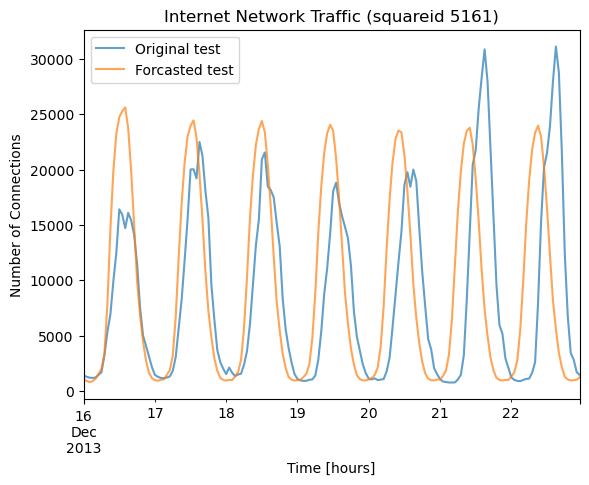

In [78]:
#train_predictions = scaler.inverse_transform(train_predictions)
predictions_5161, MAPE_5161, MAE_5161 = multi_step_prediction(5161)

#train_ = get_trainable_data # trainable data
test_5161 = get_test_data(5161).to_frame()
test_5161['Predictions'] = predictions_5161


# Plot 

axis = test_5161['Internet traffic activity'].plot(label='Original test', alpha=0.7)
test_5161['Predictions'].plot(ax=axis, label='Forcasted test', alpha=0.7)
axis.set_xlabel('Time [hours]')
axis.set_ylabel('Number of Connections')
plt.legend(loc='best')
plt.title('Internet Network Traffic (squareid 5161)')
plt.show()
plt.close()

*id = 4159*

/home/infres/mtogola-22/miniconda3/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


--- 65.72150254249573 seconds ---
MAPE 0.5179475753920206
MAE 680.4802444678023


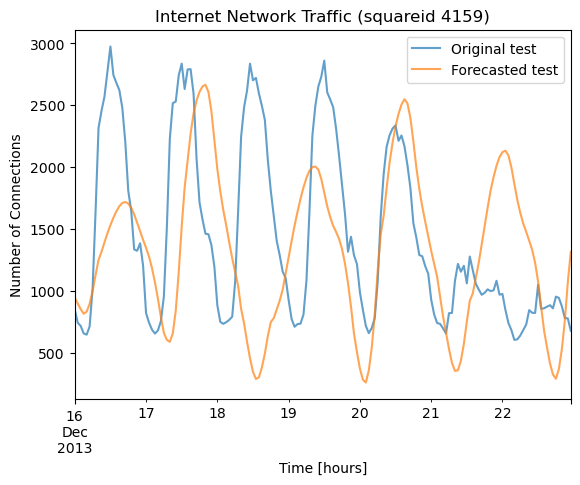

In [79]:
#train_predictions = scaler.inverse_transform(train_predictions)
predictions_4159, MAPE_4159, MAE_4159 = multi_step_prediction(4159)

#train_ = get_trainable_data # trainable data
test_4159 = get_test_data(4159).to_frame()
test_4159['Predictions'] = predictions_4159


axis = test_4159['Internet traffic activity'].plot(label='Original test', alpha=0.7)
test_4159['Predictions'].plot(ax=axis, label='Forecasted test', alpha=0.7)
axis.set_xlabel('Time [hours]')
axis.set_ylabel('Number of Connections')
plt.legend(loc='best')
plt.title('Internet Network Traffic (squareid 4159)')
plt.show()
plt.close()

*id = 4556*

/home/infres/mtogola-22/miniconda3/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


--- 64.91609358787537 seconds ---
MAPE 0.6760252669728375
MAE 1769.7294088114043


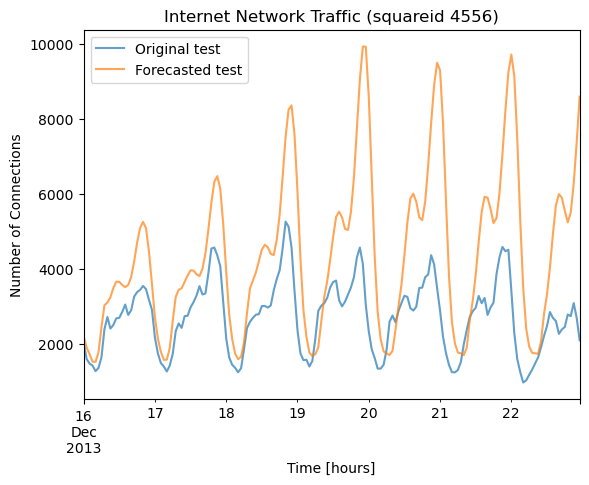

In [80]:
#train_predictions = scaler.inverse_transform(train_predictions)
predictions_4556, MAPE_4556, MAE_4556 = multi_step_prediction(4556)

#train_ = get_trainable_data # trainable data
test_4556 = get_test_data(4556).to_frame()
test_4556['Predictions'] = predictions_4556

axis = test_4556['Internet traffic activity'].plot(label='Original test', alpha=0.7)
test_4556['Predictions'].plot(ax=axis, label='Forecasted test', alpha=0.7)
axis.set_xlabel('Time [hours]')
axis.set_ylabel('Number of Connections')
plt.legend(loc='best')
plt.title('Internet Network Traffic (squareid 4556)')
plt.show()
plt.close()